In [3]:
print(sys.executable)

g:\Mi unidad\Tesis v1\mt\Scripts\python.exe


## ENTRENAMIENTO DE MODELOS EN BASE A NUESTRO DATASET PREPROCESADO ANTERIORMENTE
#### Dentro de este jupyter se presenta todo el proceso de entrenamiento de un nuevo modelo en base a los datos que recopilamos y preprocesamos en el notebook anterior. Este notebook presenta todo el proceso de entrenamiento, evaluación y ajuste fino para la clasificación de los paradigmas dentro de una señal EEG
##### Este notebook es una muestra simple de cómo poder usar la librería `Backend_DL`para un pipeline completo de formación de modelos de predicción de paradigmas EEG, con ayuda de ***EEGNET*** y *TensorFLOW* 

##### Los objetivos principales de esta librería son:

- Creación de un objeto para la preselección de los datos 
- Preselección de las clases para entrenar
- Selección de los canales a utilizar
- Creación de npz a formato compatible con entrenamiento de Keras 
- Separación de clases y undersampleo y balance de las mismas 
- Split de los datos de entrenamiento con estratificación en sujetos, sesiones o triales compatibles con el formato [MOABB](https://moabb.neurotechx.com/docs/index.html)
- Normalización de los datos para keras
- Entrenamiento general del modelo con definición de hiperparámetros 
- Aplicación de ajuste fino 
- Evaluación y métricas de los modelos

### 1) Establecer área de trabajo (Pueden ignorar esta primera celda y sólo importar la librería)

In [1]:
import os
import sys
import numpy as np

project_path = 'G:\\Mi unidad\\Tesis v1\\Movement_clasify' 
print(f"Ruta de trabajo actual: {project_path}")



os.chdir(project_path) #change directory B)
sys.path.append(project_path)


#Elegimos la ruta donde trabajaremos con colab
BASE_FOLDER = os.getcwd() #Ruta actual del proyecto

#Rutas donde tenemos demás recursos
scripts_path = os.path.join(BASE_FOLDER, 'scripts')
note_path = os.path.join(BASE_FOLDER, 'notebooks')
resources_path = os.path.join(BASE_FOLDER, 'Recursos')

#Asegurarnos de que todos existan
if os.path.exists(scripts_path): #Donde están nuestras librerían
    if scripts_path not in sys.path:
        sys.path.append(scripts_path)
        print(f"✅ Path agregado: {scripts_path}")
else: print(f"No encontrse encontró la carpeta en {scripts_path}")
if os.path.exists(note_path): #
    if note_path not in sys.path:
        sys.path.append(note_path)
        print(f"✅ Path agregado: {note_path}")
else: print(f"No encontrse encontró la carpeta en {note_path}")
if os.path.exists(resources_path):#Donde están nuestros datos
    if resources_path not in sys.path:
        sys.path.append(resources_path)
        print(f"✅ Path agregado: {resources_path}")
else: print(f"No encontrse encontró la carpeta en {resources_path}")

#Importamos nuestras librerías internas
import backend_DL_v2 as dl

Ruta de trabajo actual: G:\Mi unidad\Tesis v1\Movement_clasify
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\scripts
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\notebooks
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\Recursos


### 2) Creación de objeto y selección de canales, al crear del objeto se pueden especificar: 
- La selección de canales
- La posibilidad de undersamplear las clases mayoritarias por balance 
- Posibilidad de fusionar o no las clases imaginarias con las motoras

En el caso de este dataset, la distribución de clases quedaría de la siguiente manera: 
    "rest" -> 0

    "right_i" -> 1

    "left_i"->2

    "hands_i" -> 3

    "feet_i" -> 4

    "right_m" -> 5

    "left_m" -> 6

    "hands_m" -> 7
    
    "feet_m" -> 8

In [12]:

pick = None #Las clases que queremos elegir, izquierda y derecha 

"""En caso de querer entrenar distintas clases:
pick = [0,3,4,7,8] Rest, Manos y pies 
pick = [0,1,2,5,6] Rest, Derecha e Izquierda
pick = [0,1,2,3,4,5,6,7,8] Todas las clases 
Si quieren, también pueden evaluar dos clases si quitan el cero, DEBERÍA INCLUIR UNA FUNCIÓN DE EVALUAR EL REST VS NO REST EN EL FUTURO
Se pueden evaluar las series independientes, en caso de tener activado el argumento de fusionar, sólo se funsionarían las clases
imaginarias y motoras de la misma clase
"""

#Probamos nuestro nuevo objeto

obj = dl.Selection(pick=pick, Debug=True)



### 3) Una vez creado el objeto, se puede establecer una ruta al dataset para ejecutar y a su vez se pueden elegir los canales que se quieren usar para el entrenamiento con el atributo "pick_ch"
(Recordatorio: debo crear una función de fet channels, pues ya existe el resume_dataset pero para evitar tantos datos)

In [13]:
path_dataset = "Recursos/7_ch/101_subs/eeg_dataset_0.00015rate.npz"
obj.load(path_dataset)
obj.pick_ch(["C3..", "C4..", "Cz.."])
#obj.resume_dataset(subs=True)

✔️ Dataset cargado desde: Recursos/7_ch/101_subs/eeg_dataset_0.00015rate.npz
✔ Canales seleccionados: ['C3..', 'C4..', 'Cz..']
Nuevo shape X: (166170, 3, 160)


### 4) Una vez todos los argumentos listos, se puede usar el atributo "pipeline" para ejecutar todo lo pedido

In [14]:
obj.pipeline(undersample_rest=False, binary=True)



No se va a aplicar undersample!
✔ No se especificó pick, usando todas las clases presentes: [0, 1, 2, 3, 4, 5, 6, 7, 8] . . .
✔ Activando modo binario (rest vs no_rest)
{np.int32(0): np.int64(82325), np.int32(1): np.int64(83845)}


### 4.5) Opcionalmente, se puede usar el atributo "resume_data" para examinar los datos antes del entrenamiento

In [15]:
obj.resume_data()



X shape: (166170, 3, 160)
y shape: (166170,)
sub shape: (166170,)
trial shape: (166170,)
run shape: (166170,)
Número de clases: 2
Número de sujetos: 97

Clases:
   codigo   nombre
0       0     rest
1       1  no_rest

Conteo por clase:
0    82325
1    83845
Name: count, dtype: int64


### 5) Con el método "pick_fine" se pueden separtar los datos en aquellos datos de entrenamiento y aquellos datos de ajuste fino 
(Recordatorio: debo hacer un atributo de get_model para aquellos que no quieran dividir el dataset)

In [16]:
data_model, data_fine = obj.pick_fine(7)

✔ Sujetos entrenamiento: [  1   2   3   4   5   6   8   9  10  11  12  14  15  16  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  84  85  86  87  89  90  91  93  94  95  96  97  98  99 101
 102 103 105 106 107 108]
✔ Sujeto fine-tune: 7
Shape modelo: (164370, 3, 160)
Shape fine: (1800, 3, 160)


### 6) Entrenamiento del modelo general con "eeg_train", se establecen las épocas, el modo de estratificación, así como el tamaño de la separación de los datos de entrenamiento y validación

In [17]:
modelo, history, mean, std, keras_split, info = dl.eeg_train(
    data_model,
    mode="subject",
    epochs=60,
    debug=True
)

Modo de split: subject
Split por grupo:
  Train: 128880 muestras, grupos: [  2   3   4   6   8   9  10  11  14  16  18  19  20  21  23  24  25  27
  28  29  31  32  33  36  38  39  40  42  43  44  45  46  48  49  50  51
  52  53  54  55  56  57  59  60  64  65  66  67  68  69  70  71  73  74
  75  76  78  79  80  82  84  85  87  91  93  94  95  97  98  99 101 102
 103 105 106 108]
  Val:   17800 muestras, grupos: [ 5 12 22 35 37 47 72 77 81 96]
  Test:  17690 muestras, grupos: [  1  15  26  30  34  58  86  89  90 107]
Modo split: subject
X_train: (128880, 3, 160)
X_val: (17800, 3, 160)
X_test: (17690, 3, 160)
Antes de normalizar: (128880, 3, 160) Después de normalizar: (128880, 3, 160) Después de ajustar para Keras: (128880, 3, 160, 1)
Epoch 1/60


c:\Users\Josjuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4028/4028 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.5551 - loss: 0.6830 - val_accuracy: 0.5557 - val_loss: 0.6807
Epoch 2/60
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.5731 - loss: 0.6763 - val_accuracy: 0.5510 - val_loss: 0.6839
Epoch 3/60
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.5782 - loss: 0.6746 - val_accuracy: 0.5552 - val_loss: 0.6784
Epoch 4/60
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.5809 - loss: 0.6736 - val_accuracy: 0.5764 - val_loss: 0.6798
Epoch 5/60
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.5828 - loss: 0.6731 - val_accuracy: 0.5544 - val_loss: 0.6813
Epoch 6/60
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.5854 - loss: 0.6724 - val_accuracy: 0.5639 - val_loss: 0.6770
Epoch 7/60
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.5855 - loss: 0.6716 - val_accuracy: 0.5593 - val_loss: 0.6767
Epoch 8/60
4028/4028 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.5856 - loss: 0.6713 - val

##### Examinar modelo obtenido

553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

=== Evaluación EEGNet ===
Clases (índice -> nombre):
  0: rest
  1: no_rest

Matriz de confusión (conteos):
[[2578 6322]
 [1359 7431]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.65      0.29      0.40      8900
     no_rest       0.54      0.85      0.66      8790

    accuracy                           0.57     17690
   macro avg       0.60      0.57      0.53     17690
weighted avg       0.60      0.57      0.53     17690



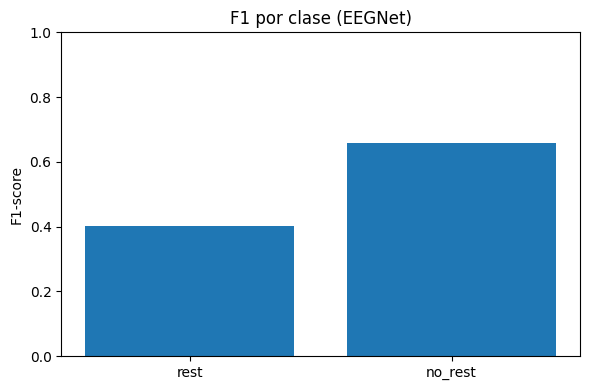

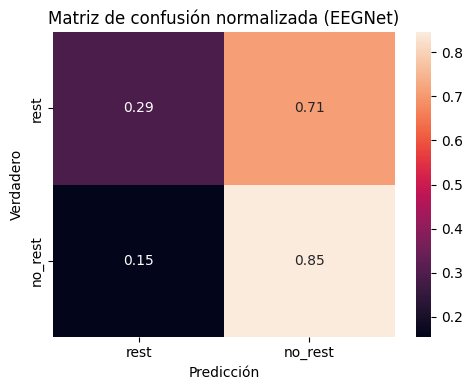

{'y_pred': array([0, 1, 1, ..., 1, 1, 1], shape=(17690,)),
 'cm': array([[2578, 6322],
        [1359, 7431]]),
 'cm_norm': array([[0.28966292, 0.71033708],
        [0.15460751, 0.84539249]]),
 'precision': array([0.65481331, 0.54031848]),
 'recall': array([0.28966292, 0.84539249]),
 'f1': array([0.40165148, 0.65927339])}

In [18]:
dl.evaluate(modelo, keras_split, obj.label_map)

In [21]:
#Guardamos el modelo y sus parámetros de normalización
clases = np.unique(pick)
path = f"Recursos/models/general/{len(np.unique(obj.sub))}_subjects/{clases}_trained_models_v1"
print(f"Guardando modelo en: {path}")

if not os.path.exists(path):
    os.makedirs(path)

dl.save_model(modelo, mean, std, path = path, name_model = f"Gmodel_{len(obj.X)}_{len(np.unique(obj.sub))}.keras", name_params = f"EEGnet_general_{len(obj.X)}_{len(np.unique(obj.sub))}.npz")


Guardando modelo en: Recursos/models/general/97_subjects/[0 1 2 5 6]_trained_models_v1


In [10]:
#Cargar modelo en caso de que ya tenegamos uno guardado
modelo, mean, std = dl.load_model(model_path = "Recursos/models/general/97_subjects/[0 1 2 5 6]_trained_models_v1/Gmodel_63245_97.keras", 
                                  params_path = "Recursos/models/general/97_subjects/[0 1 2 5 6]_trained_models_v1/EEGnet_general_63245_97.npz")


In [21]:
modelo_ft, history_ft, mean, std, keras_split_ft = dl.eeg_fine(modelo, 
                                                        data_fine, mean = mean, std = std, 
                                                        debug=False, epochs=150, lr=2e-4)


Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5203 - loss: 0.7135 - val_accuracy: 0.5944 - val_loss: 0.6678
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5291 - loss: 0.6927 - val_accuracy: 0.6000 - val_loss: 0.6629
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5442 - loss: 0.6859 - val_accuracy: 0.6056 - val_loss: 0.6615
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5554 - loss: 0.6770 - val_accuracy: 0.6056 - val_loss: 0.6618
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5641 - loss: 0.6768 - val_accuracy: 0.6278 - val_loss: 0.6616
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5873 - loss: 0.6737 - val_accuracy: 0.6722 - val_loss: 0.6619
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6000 - loss: 0.6720 - val_accuracy: 0.6722 - val_loss: 0.6617
Epoch 8/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6024 - loss: 0.6686 - val_accuracy: 0.6889 - v

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

=== Evaluación EEGNet ===
Clases (índice -> nombre):
  0: rest
  1: no_rest

Matriz de confusión (conteos):
[[ 10 195]
 [ 10 150]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.50      0.05      0.09       205
     no_rest       0.43      0.94      0.59       160

    accuracy                           0.44       365
   macro avg       0.47      0.49      0.34       365
weighted avg       0.47      0.44      0.31       365



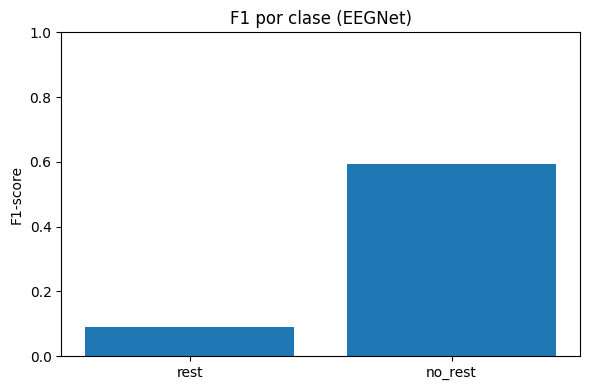

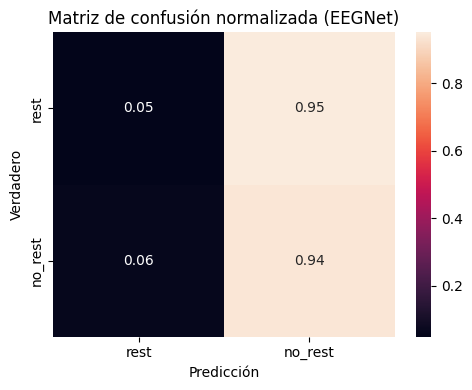

{'y_pred': array([1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1,

In [20]:
dl.evaluate(modelo_ft, keras_split_ft, obj.label_map)

In [24]:

path_f = f"Recursos/models/fined/{len(np.unique(obj.sub))}_subjects/{clases}_finned_model_v1"
print(f"Guardando modelo en: {path_f}")

if not os.path.exists(path_f):
    os.makedirs(path_f)

dl.save_model(modelo, mean, std, path = path_f, name_model = f"Fmodel_{len(obj.X)}_{len(np.unique(obj.sub))}.keras", name_params = f"EEGnet_fined_{len(obj.X)}_{len(np.unique(obj.sub))}.npz")


Guardando modelo en: Recursos/models/fined/97_subjects/[0 1 2 5 6]_finned_model_v1
